# Cross-Modal Diagnostic Observability — Stage T2-F

## RA-CB-AMW-DDET v0.2：风险自适应协变量平衡、失败修复与 blind refreeze

这一册执行最后一次透明的 development 方法修订：

- 精确复现 Stage T2-D 的 AMW-DDET v0.1；
- 在同一主动 witness 上加入二阶矩 entropy balancing；
- 用 group-aware cross-fitted Brier risk 在原 AMW 与平衡 AMW 间选择；
- 对全部强基线、27-edge 排序、dermoscopy、标签置乱和 LOTO 证书重新审计；
- 通过后冻结 RA-CB-AMW-DDET v0.2，并使旧 T3-V v0.1 草案失效。

**本阶段使用同一批 development targets，是 post-result revision，不是独立验证。** 本册不会解析 `BUSI_CAIRO_2019 / OASBUD_2017 / DERM7PT_2019` 或任何 blind outcome，也不授权 Stage 12。

普通 CPU，干净 Colab 运行时，直接 `Run all`。正式设置为 100 次 acquisition＋50 次标签置乱。

In [1]:
# @title T2-F-0. Mount Drive, verify immutable parents and revision documents, then seal protocol
import hashlib, json, os, platform, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit, logit, logsumexp
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore', category=RuntimeWarning)
try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB=False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB=True
except Exception:
    pass

LOCAL_MODE=bool(os.environ.get('DDET_LOCAL_MODE'))
DEFAULT_ROOT=Path('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability') if IN_COLAB else Path.cwd()
PROJECT_ROOT=Path(os.environ.get('CDO_PROJECT_ROOT',str(DEFAULT_ROOT)))
CODE_ROOT=PROJECT_ROOT/'05_Code'/'Cross_Modal' if not LOCAL_MODE else Path.cwd()
CM_ROOT=PROJECT_ROOT/'06_Data_Records'/'Cross_Modal' if not LOCAL_MODE else Path(os.environ.get('DDET_LOCAL_RECORD','/tmp/RA_CB_AMW_T2F_Local_Record'))
RESULT_ROOT=CM_ROOT/'StageT2-F_Development_Only_RA-CB-AMW-DDET_Risk_Adaptive_Covariate_Balance_And_Blind_Refreeze_v0.1'
P0,P1,P2,P3,P4=[RESULT_ROOT/x for x in ['00_Protocol','01_RA_CB_Replicates','02_Mechanism_And_Applicability','03_Certificates_And_Gates','04_Results']]
for path in [CODE_ROOT,P0,P1,P2,P3,P4]: path.mkdir(parents=True,exist_ok=True)

NOTEBOOK_NAME='CrossModal_StageT2-F_Development_Only_RA-CB-AMW-DDET_Risk_Adaptive_Covariate_Balance_And_Blind_Refreeze_v0.1.ipynb'
NOTEBOOK_PATH=CODE_ROOT/NOTEBOOK_NAME
THEORY_NAME='Directed_Diagnostic_Evidence_Transport_Risk_Adaptive_Covariate_Balance_Theory_v0.5.md'
METHOD_NAME='RA-CB-AMW-DDET_Method_Specification_v0.2.md'
PREREG_NAME='StageT2-F_RA-CB-AMW-DDET_Development_Revision_Freeze_v0.1.md'
T3_DRAFT_NAME='StageT3-V_RA-CB-AMW-DDET_Locked_Blind_Validation_Preregistration_DRAFT_v0.2.md'
LOCKED_MARKERS=['BUSI_CAIRO_2019','OASBUD_2017','DERM7PT_2019']

PARENT_T2D_FINAL_SHA='9feb5c20171c5c8f9aa3b63aa90b117d24dfe232c3775f40fedd2f3a6820a5fa'
PARENT_T2E_FINAL_SHA='a9ede4df1d69c3b9edf442d4b46609b481921457ed7e40ec456be165fc2b1a25'
EXPECTED={
    'edge_library':'f074467614321e4162a3aa4ad982b62edfa362d6238edeb2f69be6d4d50f09a9',
    'stage7_predictions':'4292324ae0053bdd91fb959641ad5b545b8db22967eb30fa64e83690d3871f17',
    'stage8_predictions':'e8f019d1beaf6716e780825894651318974c0780982b55d5f0481216f0c6602f',
    'stage8b_predictions':'33a8b2312df5c0e9576de1c5211e82a158177a89e321ba667252fb485a393329',
    'stage11f_predictions':'6ace342fbd6928f1041e80c446e79a501d8c23f618ebc4a3c671fc98d899a80d',
    't2d_replicates':'c6f740510c520167c2ecfbfc48fc2db88428e17ce1b96e6ad5826e507929aedb',
    't2e_new_replicates':'8c9355aa9c08899d1678a22d6ce14920206c2397ecb9b693d01bcb67ae854021',
    't2e_applicability':'5b1937382e8e28c96d5b28fad6373851bd54449101966bc3d004100f671f86d2',
    't2e_gates':'ef9a3f7d3d8b69285348b04c8e4912b3aee0f49008f2ce51cd83f31861c2e042',
    'theory':'059d43b3755572f85842eede7c3a39bc46909d0f9260cac8a0dd37d674500532',
    'method':'6ba232dde4daa4f1fa46f103133ac22338657c7ee949f4cf1b9a26e915bbcda7',
    'preregistration':'29f9999c7ff1cccb910fa1599e1a662b6edecd20f89ec5ce01482662f2f7d364',
    't3_draft':'8be317604e075199ee5e1f55ed44446b92643438753e2141a03222facf9e8ed5',
}
SEED=20260722
BUDGET=32
N_REPLICATES=int(os.environ.get('DDET_FAST_REPS','20')) if LOCAL_MODE else 100
N_NEGATIVE=int(os.environ.get('DDET_FAST_NEG','10')) if LOCAL_MODE else 50
RIDGE_C=3.0
BALANCE_RIDGE=0.1
WEIGHT_CLIP=(0.1,10.0)
MIN_BALANCE_ESS=8.0
ALPHA=0.10

def now(): return datetime.now(timezone.utc).isoformat()
def sha_file(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda:handle.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
def sha_json(value): return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',',':'),ensure_ascii=False).encode()).hexdigest()
def canonical_csv(frame): return frame.fillna('').to_csv(index=False,lineterminator='\n',float_format='%.12g')
def write_text_once(path,text):
    path=Path(path)
    if path.exists(): assert path.read_text(encoding='utf-8')==text,f'Replay conflict: {path}'
    else: path.write_text(text,encoding='utf-8')
def write_csv_once(path,frame): write_text_once(path,canonical_csv(frame))
def write_json_once(path,value): write_text_once(path,json.dumps(value,indent=2,ensure_ascii=False)+'\n')
def verify_self(path,field):
    value=json.loads(Path(path).read_text(encoding='utf-8')); claim=value[field]
    core=dict(value); core.pop(field)
    assert sha_json(core)==claim,f'Self-hash mismatch: {path}'
    return value
def seal(path,payload,hash_field,time_field):
    path=Path(path)
    if path.exists():
        old=verify_self(path,hash_field)
        for key,value in payload.items(): assert old[key]==value,f'Sealed field changed: {key}'
        return old
    value=dict(payload); value[time_field]=now(); value[hash_field]=sha_json(value)
    write_json_once(path,value); return value
def notebook_source_sha256(path):
    value=json.loads(Path(path).read_text(encoding='utf-8')); cells=[]
    for cell in value.get('cells',[]):
        if cell.get('cell_type') not in {'code','markdown'}: continue
        source=cell.get('source',[]); source=''.join(source) if isinstance(source,list) else str(source)
        cells.append({'cell_type':cell['cell_type'],'source':source.replace('\r\n','\n')})
    return sha_json(cells)

if LOCAL_MODE:
    PATHS={
        'edge_library':Path.cwd()/'edges.csv','stage7_predictions':Path.cwd()/'s7.csv',
        'stage8_predictions':Path.cwd()/'s8.csv','stage8b_predictions':Path.cwd()/'s8b.csv',
        'stage11f_predictions':Path.cwd()/'s11.csv','t2d_final':Path.cwd()/'t2_parent_final.json',
        't2d_replicates':Path.cwd()/'t2_replicates.csv','t2e_final':Path.cwd()/'t2e_final.json',
        't2e_new_replicates':Path.cwd()/'t2e_new_replicates.csv','t2e_applicability':Path.cwd()/'t2e_applicability.csv',
        't2e_gates':Path.cwd()/'t2e_gates.csv','theory':Path.cwd()/THEORY_NAME,'method':Path.cwd()/METHOD_NAME,
        'preregistration':Path.cwd()/PREREG_NAME,'t3_draft':Path.cwd()/T3_DRAFT_NAME,
    }
else:
    RETINAL=PROJECT_ROOT/'06_Data_Records'/'Retinal_DR'/'Prospective_Retinal_Blind_Test_v0.1'
    STAGE7=RETINAL/'Stage7_PostUnseal_FourDomain_Transportability_Discovery_And_DDO2_Prototype_v0.1'
    STAGE8=CM_ROOT/'Stage8_CrossModality_EdgeLibrary_Expansion_v0.1'
    STAGE8B=CM_ROOT/'Stage8B_NLM_Chest_Radiography_Access_Completion_v0.1'
    STAGE11F=CM_ROOT/'Stage11F-R_Development_Only_Directed_Edge_Assembly_And_Fit_Readiness_v0.2'
    T2D=CM_ROOT/'StageT2-D_Development_Only_AMW-DDET_Active_Minimal_Witness_Certificate_v0.1'
    T2E=CM_ROOT/'StageT2-E_Development_Only_Paper_Grade_Baselines_Ablations_Applicability_And_Blind_Readiness_v0.1'
    THEORY_DIR=PROJECT_ROOT/'03_Theory'/'Directed_Diagnostic_Evidence_Transport_v0.5'
    PATHS={
        'edge_library':STAGE11F/'03_Expanded_Edge_Library'/'Stage11F-R_FourModality_Eligible_Edge_Library_v0.2.csv',
        'stage7_predictions':STAGE7/'01_Four_Domain_Edge_Matrix'/'Stage7_FourDomain_Unit_Predictions_v0.1.csv',
        'stage8_predictions':STAGE8/'05_Unsealed_Discovery'/'Stage8_Evaluated_Unit_Predictions_v0.1.csv',
        'stage8b_predictions':STAGE8B/'05_Unsealed_Chest_Discovery'/'Stage8B_Evaluated_Chest_Unit_Predictions_v0.1.csv',
        'stage11f_predictions':STAGE11F/'02_Development_Transfer_Outcomes'/'Stage11F-R_Evaluated_Ultrasound_Target_Predictions_v0.2.csv',
        't2d_final':T2D/'04_Results'/'StageT2-D_Complete_v0.1.json',
        't2d_replicates':T2D/'01_Replicate_Results'/'StageT2-D_All_Acquisition_Replicates_v0.1.csv',
        't2e_final':T2E/'04_Results'/'StageT2-E_Complete_v0.1.json',
        't2e_new_replicates':T2E/'01_New_Baselines_And_Ablations'/'StageT2-E_New_Baseline_And_Ablation_Replicates_v0.1.csv',
        't2e_applicability':T2E/'02_Applicability'/'StageT2-E_Applicability_Target_Summary_And_LOTO_v0.1.csv',
        't2e_gates':T2E/'03_Gates_And_Blind_Readiness'/'StageT2-E_Frozen_Gates_v0.1.csv',
        'theory':THEORY_DIR/THEORY_NAME,'method':THEORY_DIR/METHOD_NAME,
        'preregistration':PROJECT_ROOT/'04_Study_Design'/PREREG_NAME,
        't3_draft':PROJECT_ROOT/'04_Study_Design'/T3_DRAFT_NAME,
    }

assert NOTEBOOK_PATH.is_file(),f'Notebook must be stored at {NOTEBOOK_PATH} before Run all'
missing=[str(path) for path in PATHS.values() if not path.is_file()]
assert not missing,'Missing immutable inputs:\n'+'\n'.join(missing)
t2d=verify_self(PATHS['t2d_final'],'final_record_sha256')
t2e=verify_self(PATHS['t2e_final'],'final_record_sha256')
assert t2d['final_record_sha256']==PARENT_T2D_FINAL_SHA and t2e['final_record_sha256']==PARENT_T2E_FINAL_SHA
assert t2e['frozen_gates_passed']==t2e['frozen_gates_total']==11
assert t2e['stage12_authorised'] is False and t2e['locked_blind_assets_touched'] is False
for role,expected in EXPECTED.items(): assert sha_file(PATHS[role])==expected,f'Hash mismatch: {role}'
t2e_gates=pd.read_csv(PATHS['t2e_gates']); assert len(t2e_gates)==11 and t2e_gates.passed.astype(str).str.lower().eq('true').all()
resolved='|'.join(str(path) for key,path in PATHS.items() if key not in {'t3_draft'})
assert not any(marker.lower() in resolved.lower() for marker in LOCKED_MARKERS),'Locked marker resolved in executable inputs'

protocol_payload={
    'stage':'StageT2-F','analysis':'development_only_post_result_risk_adaptive_covariate_balance_revision',
    'parent_t2d_final_sha256':PARENT_T2D_FINAL_SHA,'parent_t2e_final_sha256':PARENT_T2E_FINAL_SHA,
    'input_sha256':EXPECTED,'notebook_source_sha256':notebook_source_sha256(NOTEBOOK_PATH),
    'primary_budget':BUDGET,'seed':SEED,'formal_replicates':100,'formal_negative_replicates':50,
    'ridge_C':RIDGE_C,'balance_dictionary':'z_plus_z_squared','balance_ridge':BALANCE_RIDGE,
    'weight_clip':list(WEIGHT_CLIP),'minimum_balance_ess':MIN_BALANCE_ESS,
    'selector':'lower_group_equal_crossfitted_brier_strict_tie_to_unbalanced',
    'post_result_revision':True,'confirmatory_claim':False,'stage12_authorised':False,
    'locked_blind_assets_touched':False,'supersedes_t3_v0_1':True,
}
protocol=seal(P0/'StageT2-F_RA-CB-AMW-DDET_Protocol_Seal_v0.1.json',protocol_payload,'seal_sha256','sealed_utc')
commitment=pd.DataFrame([{'role':role,'path':str(path),'size_bytes':path.stat().st_size,'sha256':sha_file(path)} for role,path in PATHS.items()])
write_csv_once(P0/'StageT2-F_Frozen_Input_Commitment_v0.1.csv',commitment)
environment_path=P0/'StageT2-F_Execution_Environment_v0.1.json'
environment_core={'python':sys.version,'platform':platform.platform(),'numpy':np.__version__,'pandas':pd.__version__,
    'scipy':__import__('scipy').__version__,'sklearn':__import__('sklearn').__version__,'local_fast_mode':LOCAL_MODE,
    'replicates_executed':N_REPLICATES,'negative_replicates_executed':N_NEGATIVE}
if environment_path.exists():
    old=json.loads(environment_path.read_text(encoding='utf-8'))
    for key,value in environment_core.items(): assert old[key]==value,f'Environment changed: {key}'
else: write_json_once(environment_path,{'created_utc':now(),**environment_core})
print('T2-D parent:',t2d['final_record_sha256'])
print('T2-E parent:',t2e['final_record_sha256'])
print('T2-F protocol seal:',protocol['seal_sha256'])
print('Post-result development revision is explicit. Blind outcomes remain unresolved.')

Mounted at /content/drive
T2-D parent: 9feb5c20171c5c8f9aa3b63aa90b117d24dfe232c3775f40fedd2f3a6820a5fa
T2-E parent: a9ede4df1d69c3b9edf442d4b46609b481921457ed7e40ec456be165fc2b1a25
T2-F protocol seal: c3f4ae7200b3d3f8b361a07c4300644785dc249ee24f25df862be8e487686557
Post-result development revision is explicit. Blind outcomes remain unresolved.


In [2]:
# @title T2-F-1. Reconstruct the same 13 targets and audit all parent AUCs
def prep_predictions(path,modality):
    data=pd.read_csv(path)
    unit='unit_id' if 'unit_id' in data.columns else 'sample_id'
    label='label' if 'label' in data.columns else 'binary_label'
    if 'logit' in data.columns: score='logit'
    elif 'decision_score' in data.columns: score='decision_score'
    else:
        data['_score']=logit(np.clip(data['probability'].astype(float),1e-6,1-1e-6)); score='_score'
    if 'group_id' not in data.columns:
        data['group_id']=data[unit].astype(str).str.replace(r'__EYE_(left|right)$','',regex=True)
        mask=data[unit].astype(str).str.contains('__EYE_')
        data.loc[~mask,'group_id']=data.loc[~mask,unit].astype(str)
    consistency=data.groupby(['target',unit])[[label,'group_id']].nunique()
    assert consistency.max().max()==1,'Inconsistent labels/groups across source scores'
    meta=data.groupby(['target',unit]).agg(label=(label,'first'),group_id=('group_id','first')).reset_index()
    wide=data.pivot_table(index=['target',unit],columns='source',values=score,aggfunc='mean').reset_index()
    wide=wide.merge(meta,on=['target',unit],validate='one_to_one'); wide['modality']=modality
    return wide

edge_library=pd.read_csv(PATHS['edge_library'])
assert len(edge_library)==30 and edge_library.edge_id.nunique()==30
all_scores=pd.concat([
    prep_predictions(PATHS['stage7_predictions'],'retinal_fundus'),
    prep_predictions(PATHS['stage8_predictions'],'dermoscopy'),
    prep_predictions(PATHS['stage8b_predictions'],'chest_radiography'),
    prep_predictions(PATHS['stage11f_predictions'],'breast_ultrasound'),
],ignore_index=True,sort=False)

target_tables={}; overview=[]; auc_checks=[]
for target,data in all_scores.groupby('target'):
    edges=edge_library[edge_library.target==target].copy(); sources=edges.source.tolist()
    assert sources and all(source in data.columns for source in sources)
    data=data.copy(); data['group_id']=data.group_id.astype(str)
    eligible=data.group_id.nunique()>=40
    overview.append({'target':target,'modality':data.modality.iloc[0],'units':len(data),'independent_groups':data.group_id.nunique(),'edges':len(edges),'eligible':eligible})
    for _,edge in edges.iterrows():
        empirical=roc_auc_score(data.label.astype(int),data[edge.source].astype(float))
        auc_checks.append({'source':edge.source,'target':target,'published_auc':edge.target_auc,'recomputed_auc':empirical,'absolute_difference':abs(empirical-edge.target_auc)})
    if eligible: target_tables[target]=(data,edges,sources)
overview=pd.DataFrame(overview).sort_values(['modality','target']).reset_index(drop=True)
auc_checks=pd.DataFrame(auc_checks)
assert len(target_tables)==13 and sum(len(value[1]) for value in target_tables.values())==27
assert auc_checks.absolute_difference.max()<0.005

parent_results=pd.read_csv(PATHS['t2d_replicates'])
t2e_new=pd.read_csv(PATHS['t2e_new_replicates'])
assert len(parent_results)==60450 and parent_results[parent_results.budget==32][['source','target']].drop_duplicates().shape[0]==27
assert set(parent_results.method)=={'random_direct','random_logistic_plugin','random_joint_gmm','active_direct','amw_ddet'}
assert {'ssme_kde_aligned','at_auc_adaptation','active_single_score_plugin'}.issubset(set(t2e_new.method))
write_csv_once(P0/'StageT2-F_Target_Eligibility_And_Parent_Audit_v0.1.csv',overview)
write_csv_once(P0/'StageT2-F_Parent_AUC_Recomputation_Audit_v0.1.csv',auc_checks)
display(overview)
print('Recovered 13 eligible development targets and 27 edges; BUS-UCLM remains excluded without deleting its 3 ledger edges.')

,target,modality,units,independent_groups,edges,eligible
0,BUSI_WHU_2025_V3,breast_ultrasound,186,163,2,True
1,BUS_BRA_2024,breast_ultrasound,377,212,2,True
2,BUS_UCLM_2025_V3,breast_ultrasound,65,7,3,False
3,RODRIGUES_BUI_2017,breast_ultrasound,48,48,2,True
4,Montgomery_CXR,chest_radiography,56,56,2,True
5,Shenzhen_CXR,chest_radiography,166,166,2,True
6,TBX11K,chest_radiography,500,500,2,True
7,HAM10000,dermoscopy,466,466,2,True
8,ISIC_MSK1,dermoscopy,157,138,2,True
9,ISIC_UDA1,dermoscopy,139,139,2,True


Recovered 13 eligible development targets and 27 edges; BUS-UCLM remains excluded without deleting its 3 ledger edges.


In [3]:
# @title T2-F-2. Frozen acquisition, entropy balance, cross-fitted candidates, and AUC functional
def weighted_auc(scores,probabilities):
    scores=np.asarray(scores,float); p=np.asarray(probabilities,float); n=1-p
    denominator=p.sum()*n.sum()
    if denominator<=0: return np.nan
    order=np.argsort(scores,kind='mergesort'); scores,p,n=scores[order],p[order],n[order]
    numerator=0.0; negatives_before=0.0
    starts=np.r_[0,np.flatnonzero(np.diff(scores))+1]; ends=np.r_[starts[1:],len(scores)]
    for start,end in zip(starts,ends):
        p_here=p[start:end].sum(); n_here=n[start:end].sum()
        numerator+=p_here*(negatives_before+0.5*n_here); negatives_before+=n_here
    return float(numerator/denominator)

def choose_groups(n,budget,rng,design,active=True):
    if not active: return rng.choice(n,budget,replace=False)
    anchors=max(2,int(np.ceil(budget*0.25)))
    selected=list(rng.choice(n,anchors,replace=False)); used=np.zeros(n,bool); used[selected]=True
    inverse=np.linalg.inv(np.eye(design.shape[1])+design[selected].T@design[selected])
    while len(selected)<budget:
        gains=np.einsum('ij,jk,ik->i',design,inverse,design); gains[used]=-np.inf
        index=int(np.argmax(gains+rng.normal(0,1e-12,n)))
        vector=design[index]; product=inverse@vector
        inverse-=np.outer(product,product)/(1+vector@product)
        selected.append(index); used[index]=True
    return np.asarray(selected)

def balance_features(group_x): return np.column_stack([group_x,group_x**2])

def entropy_balance_weights(sample_phi,target_phi,ridge=BALANCE_RIDGE,clip=WEIGHT_CLIP):
    sample_phi=np.asarray(sample_phi,float); target_phi=np.asarray(target_phi,float)
    target_mean=target_phi.mean(0); center=sample_phi.mean(0); scale=sample_phi.std(0)+1e-6
    a=(sample_phi-center)/scale; mu=(target_mean-center)/scale
    def objective(lam):
        raw=np.clip(a@lam,-30,30); shifted=raw-raw.max(); weight=np.exp(shifted); weight/=weight.sum()
        value=np.log(np.exp(raw).mean())-mu@lam+0.5*ridge*np.sum(lam**2)
        gradient=weight@a-mu+ridge*lam
        return value,gradient
    fit=minimize(lambda value:objective(value),np.zeros(a.shape[1]),jac=True,method='L-BFGS-B')
    valid=bool(fit.success and np.all(np.isfinite(fit.x)))
    lam=fit.x if valid else np.zeros(a.shape[1])
    raw=np.clip(a@lam,-30,30); raw-=raw.max(); weight=np.exp(raw); weight/=weight.mean(); weight=np.clip(weight,clip[0],clip[1])
    weighted_mean=np.average(sample_phi,axis=0,weights=weight)
    raw_scale=target_phi.std(0)+1e-6
    standardized_residual=float(np.max(np.abs((weighted_mean-target_mean)/raw_scale)))
    ess=float(weight.sum()**2/np.sum(weight**2))
    diagnostics={'optimizer_success':valid,'weight_min':float(weight.min()),'weight_max':float(weight.max()),
        'weight_ess':ess,'balance_residual_max_standardized':standardized_residual}
    return weight,diagnostics

def candidate_posterior(x,y,groups,unique_groups,selected_indices,balanced):
    selected_groups=unique_groups[selected_indices]; witness=np.isin(groups,selected_groups)
    if len(np.unique(y[witness]))<2: return None,None
    group_x=np.asarray([x[groups==group].mean(0) for group in unique_groups]); phi=balance_features(group_x)
    group_lookup={group:index for index,group in enumerate(unique_groups)}
    if balanced:
        full_weight,diagnostics=entropy_balance_weights(phi[selected_indices],phi)
        lookup=dict(zip(selected_groups,full_weight)); unit_weight=np.asarray([lookup[group] for group in groups[witness]],float)
    else:
        diagnostics={'optimizer_success':True,'weight_min':1.0,'weight_max':1.0,'weight_ess':float(len(selected_groups)),'balance_residual_max_standardized':np.nan}
        unit_weight=np.ones(witness.sum())
    model=LogisticRegression(C=RIDGE_C,solver='lbfgs',max_iter=3000).fit(x[witness],y[witness],sample_weight=unit_weight)
    eta=model.predict_proba(x)[:,1]
    local=np.flatnonzero(witness); local_groups=groups[witness]; folds=min(5,len(pd.unique(local_groups)))
    splitter=GroupKFold(folds)
    for train,test in splitter.split(x[witness],y[witness],local_groups):
        if len(np.unique(y[witness][train]))<2: continue
        train_groups=np.asarray(pd.unique(local_groups[train]))
        if balanced:
            indices=np.asarray([group_lookup[group] for group in train_groups])
            fold_weight,_=entropy_balance_weights(phi[indices],phi)
            lookup=dict(zip(train_groups,fold_weight)); train_weight=np.asarray([lookup[group] for group in local_groups[train]],float)
        else: train_weight=np.ones(len(train))
        fold=LogisticRegression(C=RIDGE_C,solver='lbfgs',max_iter=3000).fit(x[witness][train],y[witness][train],sample_weight=train_weight)
        eta[local[test]]=fold.predict_proba(x[witness][test])[:,1]
    return eta,diagnostics

def group_brier(y,eta,groups,selected_groups):
    return np.asarray([np.mean((y[groups==group]-eta[groups==group])**2) for group in selected_groups],float)

def soft_selector_weight(loss_u,loss_cb):
    difference=loss_cb-loss_u; mean=float(difference.mean()); se=float(difference.std(ddof=1)/np.sqrt(len(difference)))
    return float(1/(1+np.exp(np.clip(mean/max(se,1e-8),-30,30))))

print('Frozen RA-CB candidates defined: AMW-U, AMW-CB2, strict group-CV selector, posterior AUC integration.')

Frozen RA-CB candidates defined: AMW-U, AMW-CB2, strict group-CV selector, posterior AUC integration.


In [4]:
# @title T2-F-3. Run 100 formal revisions and 50 label-permutation controls
rows=[]; diagnostic_rows=[]; skip_rows=[]
for target,(data,edges,sources) in target_tables.items():
    raw=data[sources].to_numpy(float); x=(raw-raw.mean(0))/(raw.std(0)+1e-9)
    y=data.label.to_numpy(int); groups=data.group_id.astype(str).to_numpy(); unique_groups=np.asarray(pd.unique(groups))
    group_x=np.asarray([x[groups==group].mean(0) for group in unique_groups]); design=np.c_[np.ones(len(unique_groups)),group_x]
    edge_lookup=edges.set_index('source'); truths={source:roc_auc_score(y,x[:,index]) for index,source in enumerate(sources)}
    for replicate in range(N_REPLICATES):
        base_seed=SEED+replicate*1009+BUDGET*17+sum(map(ord,target))
        selected=choose_groups(len(unique_groups),BUDGET,np.random.default_rng(base_seed+1),design,True)
        selected_groups=unique_groups[selected]; witness=np.isin(groups,selected_groups)
        if len(np.unique(y[witness]))<2:
            skip_rows.append({'target':target,'replicate':replicate,'stage':'formal','reason':'single_witness_class'}); continue
        eta_u,diag_u=candidate_posterior(x,y,groups,unique_groups,selected,False)
        eta_cb,diag_cb=candidate_posterior(x,y,groups,unique_groups,selected,True)
        if eta_u is None:
            skip_rows.append({'target':target,'replicate':replicate,'stage':'formal','reason':'unbalanced_fit_failed'}); continue
        cb_admissible=bool(eta_cb is not None and diag_cb['optimizer_success'] and diag_cb['weight_ess']>=MIN_BALANCE_ESS)
        loss_u=group_brier(y,eta_u,groups,selected_groups)
        loss_cb=group_brier(y,eta_cb,groups,selected_groups) if eta_cb is not None else np.full(len(selected_groups),np.inf)
        select_cb=bool(cb_admissible and loss_cb.mean()<loss_u.mean())
        eta_ra=eta_cb if select_cb else eta_u
        soft_weight=soft_selector_weight(loss_u,loss_cb) if cb_admissible else 0.0
        eta_soft=(1-soft_weight)*eta_u+soft_weight*eta_cb if eta_cb is not None else eta_u
        diagnostic_rows.append({'target':target,'modality':data.modality.iloc[0],'replicate':replicate,
            'selected_candidate':'AMW-CB2' if select_cb else 'AMW-U','balance_selected':select_cb,'cb_admissible':cb_admissible,
            'cv_brier_amw_u':float(loss_u.mean()),'cv_brier_amw_cb2':float(loss_cb.mean()),
            'cv_brier_difference_cb2_minus_u':float(loss_cb.mean()-loss_u.mean()),'soft_selector_weight':soft_weight,**diag_cb})
        for index,source in enumerate(sources):
            edge=edge_lookup.loc[source]; common={'target':target,'modality':data.modality.iloc[0],'source':source,'edge_id':edge.edge_id,
                'budget':BUDGET,'replicate':replicate,'true_auc':truths[source],'source_validation_auc':edge.source_validation_auc,
                'retention_threshold':edge.source_validation_auc-0.15,'independent_groups':len(unique_groups),
                'witness_units':int(witness.sum()),'witness_prevalence':float(y[witness].mean()),'balance_selected':select_cb}
            estimates={'amw_u_recomputed':weighted_auc(x[:,index],eta_u),
                'amw_cb2':weighted_auc(x[:,index],eta_cb) if eta_cb is not None else np.nan,
                'ra_cb_amw_ddet':weighted_auc(x[:,index],eta_ra),'soft_ra_cb_audit':weighted_auc(x[:,index],eta_soft)}
            for method,estimate in estimates.items():
                if np.isfinite(estimate): rows.append({**common,'method':method,'estimate_auc':estimate})
                else: skip_rows.append({'target':target,'replicate':replicate,'stage':method,'reason':'nonfinite_estimate'})
    print('Formal revisions completed:',target)

new_results=pd.DataFrame(rows); new_results['absolute_error']=(new_results.estimate_auc-new_results.true_auc).abs()
diagnostics=pd.DataFrame(diagnostic_rows)
skips=pd.DataFrame(skip_rows,columns=['target','replicate','stage','reason'])
assert {'amw_u_recomputed','amw_cb2','ra_cb_amw_ddet','soft_ra_cb_audit'}.issubset(set(new_results.method))

# Exact parent AMW reproduction: every budget-32 edge x replicate, not only aggregate metrics.
parent_amw=parent_results[(parent_results.budget==BUDGET)&(parent_results.method=='amw_ddet')][['target','source','replicate','estimate_auc']]
recomputed=new_results[new_results.method=='amw_u_recomputed'][['target','source','replicate','estimate_auc']]
audit=parent_amw.merge(recomputed,on=['target','source','replicate'],suffixes=('_parent','_recomputed'),validate='one_to_one')
audit['absolute_difference']=(audit.estimate_auc_parent-audit.estimate_auc_recomputed).abs()
assert len(audit)==27*N_REPLICATES and audit.absolute_difference.max()<1e-10

negative=[]
for target,(data,edges,sources) in target_tables.items():
    raw=data[sources].to_numpy(float); x=(raw-raw.mean(0))/(raw.std(0)+1e-9)
    y=data.label.to_numpy(int); groups=data.group_id.astype(str).to_numpy(); unique_groups=np.asarray(pd.unique(groups))
    group_x=np.asarray([x[groups==group].mean(0) for group in unique_groups]); design=np.c_[np.ones(len(unique_groups)),group_x]
    for replicate in range(N_NEGATIVE):
        rng=np.random.default_rng(SEED+900000+replicate*1009+sum(map(ord,target)))
        selected=choose_groups(len(unique_groups),BUDGET,rng,design,True); selected_groups=unique_groups[selected]; witness=np.isin(groups,selected_groups)
        y_perm=y.copy(); y_perm[witness]=rng.permutation(y[witness])
        if len(np.unique(y_perm[witness]))<2: continue
        eta_u,_=candidate_posterior(x,y_perm,groups,unique_groups,selected,False)
        eta_cb,diag_cb=candidate_posterior(x,y_perm,groups,unique_groups,selected,True)
        cb_admissible=bool(eta_cb is not None and diag_cb['optimizer_success'] and diag_cb['weight_ess']>=MIN_BALANCE_ESS)
        loss_u=group_brier(y_perm,eta_u,groups,selected_groups); loss_cb=group_brier(y_perm,eta_cb,groups,selected_groups) if eta_cb is not None else np.full(len(selected_groups),np.inf)
        eta=eta_cb if cb_admissible and loss_cb.mean()<loss_u.mean() else eta_u
        for index,source in enumerate(sources):
            estimate=weighted_auc(x[:,index],eta)
            negative.append({'target':target,'modality':data.modality.iloc[0],'source':source,'replicate':replicate,
                'estimate_auc':estimate,'absolute_deviation_from_0_5':abs(estimate-0.5)})
negative=pd.DataFrame(negative)

write_csv_once(P1/'StageT2-F_RA-CB_All_Replicates_v0.1.csv',new_results)
write_csv_once(P1/'StageT2-F_Skipped_Replicates_v0.1.csv',skips)
write_csv_once(P2/'StageT2-F_Selector_And_Balance_Diagnostics_v0.1.csv',diagnostics)
write_csv_once(P2/'StageT2-F_AMW_U_Exact_Parent_Reproduction_v0.1.csv',audit)
write_csv_once(P2/'StageT2-F_Label_Permutation_Negative_Control_v0.1.csv',negative)
print('New result rows:',len(new_results),'selector rows:',len(diagnostics),'negative rows:',len(negative),'skips:',len(skips))

Formal revisions completed: APTOS_2019
Formal revisions completed: BUSI_WHU_2025_V3
Formal revisions completed: BUS_BRA_2024
Formal revisions completed: DeepDRiD
Formal revisions completed: EyePACS_2015
Formal revisions completed: HAM10000
Formal revisions completed: IDRiD
Formal revisions completed: ISIC_MSK1
Formal revisions completed: ISIC_UDA1
Formal revisions completed: Montgomery_CXR
Formal revisions completed: RODRIGUES_BUI_2017
Formal revisions completed: Shenzhen_CXR
Formal revisions completed: TBX11K
New result rows: 10800 selector rows: 1300 negative rows: 1350 skips: 0


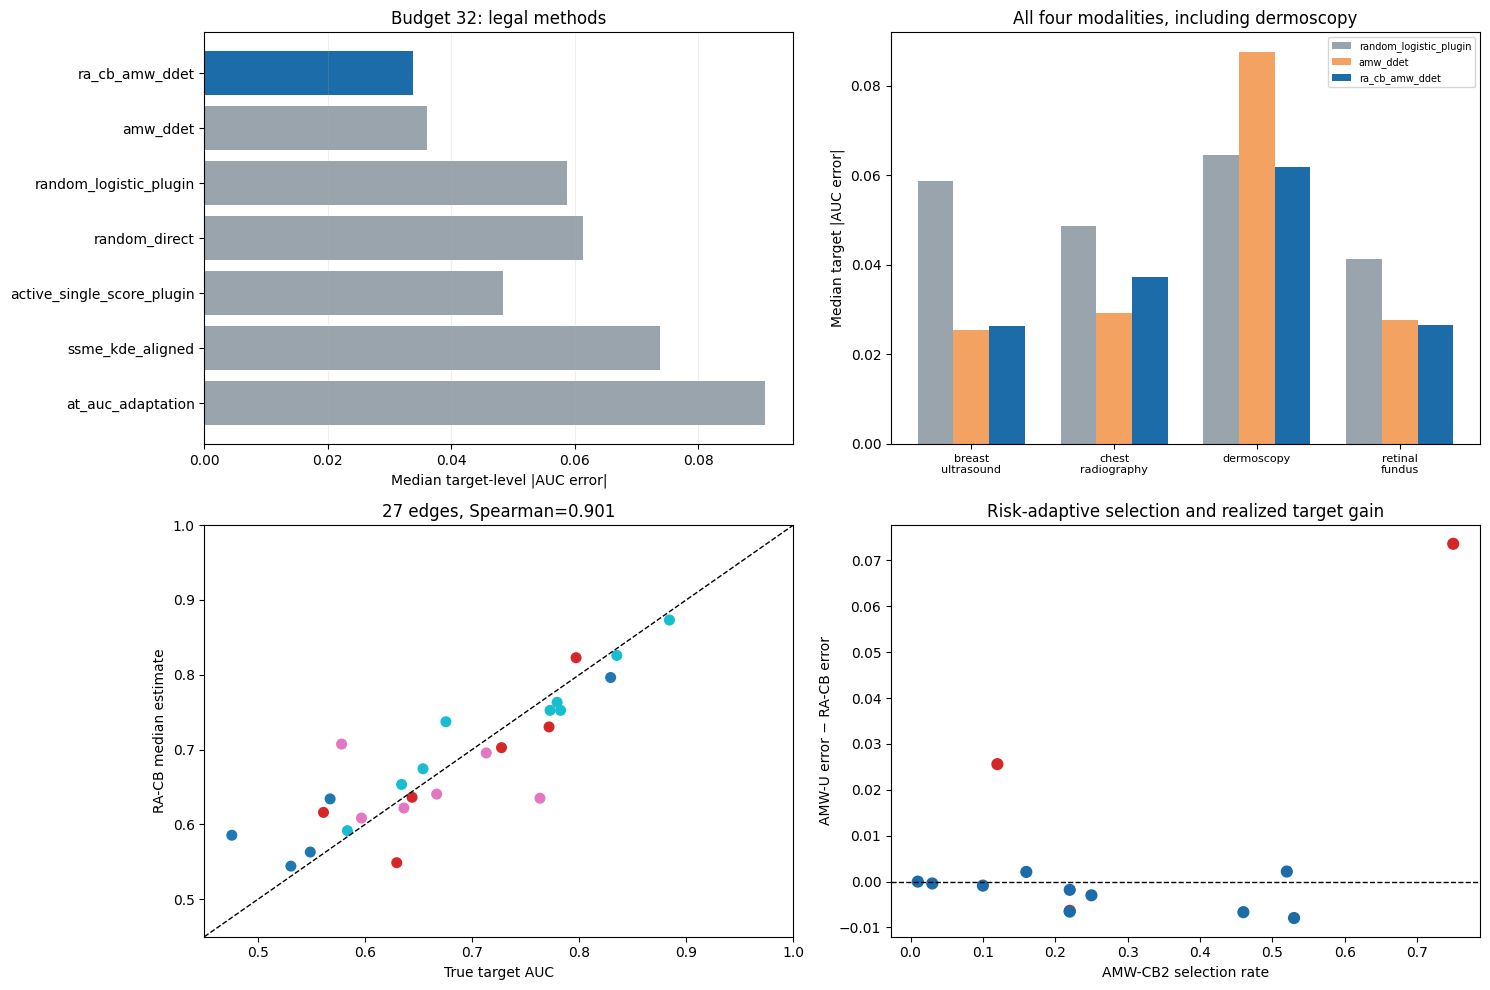

,method,median,mean,max
6,ra_cb_amw_ddet,0.033826,0.041466,0.084783
3,amw_ddet,0.036025,0.046853,0.107008
4,amw_u_recomputed,0.036025,0.046853,0.107008
11,soft_ra_cb_audit,0.038767,0.043578,0.078530
1,active_single_score_plugin,0.048406,0.055256,0.116972
2,amw_cb2,0.052656,0.052435,0.087173
10,random_single_score_plugin,0.053931,0.055112,0.085606
9,random_logistic_plugin,0.058710,0.051035,0.073913
7,random_direct,0.061348,0.058625,0.092033
8,random_joint_gmm,0.061972,0.072775,0.131658


,competitor,targets,competitor_median_mae,ra_cb_median_mae,median_error_reduction,mean_error_reduction,exact_one_sided_signflip_p
0,random_direct,13,0.061348,0.033826,0.019526,0.017159,0.003174
1,random_logistic_plugin,13,0.058710,0.033826,0.005919,0.009569,0.032959
2,amw_ddet,13,0.036025,0.033826,-0.000866,0.005388,0.260620
3,ssme_kde_aligned,13,0.073713,0.033826,0.042463,0.046354,0.000244
4,at_auc_adaptation,13,0.090820,0.033826,0.053606,0.046911,0.000122
5,active_single_score_plugin,13,0.048406,0.033826,0.001751,0.013790,0.035400


method,modality,amw_ddet,ra_cb_amw_ddet,random_direct,random_logistic_plugin
0,breast_ultrasound,0.025513,0.026379,0.066257,0.058710
1,chest_radiography,0.029281,0.037214,0.050909,0.048633
2,dermoscopy,0.087560,0.061952,0.074433,0.064463
3,retinal_fundus,0.027693,0.026593,0.043987,0.041366


,target,modality,balance_selection_rate,median_brier_difference,median_weight_ess,minimum_weight_ess,median_balance_residual,inadmissible_rate,amw_u_recomputed,amw_cb2,ra_cb_amw_ddet,candidate_oracle,selector_regret
0,APTOS_2019,retinal_fundus,0.03,0.055739,9.705162,5.626968,0.099605,0.3,0.047921,0.072994,0.048323,0.047921,0.000403
1,BUSI_WHU_2025_V3,breast_ultrasound,0.16,0.022453,15.505396,10.382998,0.189973,0.0,0.086899,0.068283,0.084783,0.068283,0.016500
2,BUS_BRA_2024,breast_ultrasound,0.22,0.013754,14.379006,9.886080,0.232387,0.0,0.014742,0.049420,0.016524,0.014742,0.001782
3,DeepDRiD,retinal_fundus,0.25,0.002602,22.651313,19.816154,0.133351,0.0,0.014965,0.026057,0.017951,0.014965,0.002986
4,EyePACS_2015,retinal_fundus,0.01,0.034907,14.776647,10.772430,0.189762,0.0,0.019360,0.059465,0.019360,0.019360,0.000000
5,HAM10000,dermoscopy,0.12,0.023249,13.740425,10.073566,0.380981,0.0,0.087560,0.066186,0.061952,0.066186,-0.004234
6,IDRiD,retinal_fundus,0.52,-0.000774,18.734756,14.002164,0.093478,0.0,0.036025,0.036812,0.033826,0.036025,-0.002199
7,ISIC_MSK1,dermoscopy,0.22,0.009199,21.601264,19.255025,0.197349,0.0,0.057014,0.062399,0.063376,0.057014,0.006361
8,ISIC_UDA1,dermoscopy,0.75,-0.009431,24.734704,23.800243,0.256092,0.0,0.107008,0.028867,0.033369,0.028867,0.004503
9,Montgomery_CXR,chest_radiography,0.53,-0.000507,27.380576,26.351591,0.053723,0.0,0.029281,0.052656,0.037214,0.029281,0.007932


,gate,observed,threshold,passed
0,G1_immutable_parents,T2-D 9feb5c20171c5c8f9aa3b63aa90b117d24dfe232c...,all exact,True
1,G2_amw_u_exact_reproduction,0.0,2700/2700; max <=1e-10,True
2,G3_revision_coverage,13 targets / 27 edges / 0 skips,13 / 27; explicit skips,True
3,G4_primary_mae,0.033826,<=0.04,True
4,G5_vs_random_logistic,RA=0.033826; logistic=0.058710; p=0.032959,RA lower; p<=0.05,True
5,G6_vs_random_direct,improvement=0.448618; p=0.003174,>=0.30; p<=0.05,True
6,G7_modality_and_dermoscopy_repair,4/4; derm RA=0.061952; logistic=0.064463,4/4; derm RA<=logistic,True
7,G8_edge_rank,0.901099,>=0.85,True
8,G9_recalibrated_certificate,r=0.16229985; coverage=0.981111; decision=0.24...,coverage>=0.90; decision>=0.10; wrong<=0.05,True
9,G10_label_permutation,0.045923,<=0.05,True



===== STAGE T2-F COMPLETE =====
# Stage T2-F RA-CB-AMW-DDET result

- Decision: `AUTHORISE_RA_CB_AMW_DDET_V0_2_FREEZE_AND_T3_V0_2_PREREGISTRATION_ONLY`
- Frozen gates: `12 / 12`
- RA-CB target-level median MAE: `0.033826`
- Random-logistic / random-direct MAE: `0.058710 / 0.061348`
- Relative improvement vs random-logistic / direct: `42.38% / 44.86%`
- Exact target-cluster p vs random-logistic / direct: `0.032959 / 0.003174`
- Parent AMW MAE and paired p: `0.036025` / `0.260620`
- 27-edge Spearman: `0.901099`
- Dermoscopy RA-CB / parent AMW / random-logistic: `0.061952 / 0.087560 / 0.064463`
- New frozen conformal radius: `0.16229985`
- Coverage / decision coverage / wrong-decision rate: `0.981111 / 0.242222 / 0.009174`
- Label-permutation median |AUC-0.5|: `0.045923`

- Post-result development revision: `True`
- Independent validation: `False`
- Stage 12 authorised: `False`
- Locked blind assets touched: `False`
- T3-V v0.1 superseded: `True`

Passing freezes RA-CB-AMW-DDET v0.2 and 

In [5]:
# @title T2-F-4. Target inference, modality repair, new certificates, 12 gates, and final freeze record
def exact_signflip(differences):
    values=pd.Series(differences).dropna().to_numpy(float); observed=values.mean(); null=[]
    for mask in range(1<<len(values)):
        signs=np.asarray([1 if (mask>>index)&1 else -1 for index in range(len(values))])
        null.append(np.mean(values*signs))
    return float(np.mean(np.asarray(null)>=observed))

parent_primary=parent_results[parent_results.budget==BUDGET].copy()
t2e_legal=t2e_new[(t2e_new.budget==BUDGET)&(t2e_new.method!='active_no_crossfit_plugin')].copy()
combined=pd.concat([parent_primary,t2e_legal,new_results],ignore_index=True,sort=False)
target_error=combined.groupby(['method','target','modality'],as_index=False).absolute_error.median()
method_summary=target_error.groupby('method').absolute_error.agg(['median','mean','max']).reset_index().sort_values('median')
edge_summary=combined.groupby(['method','source','target','modality'],as_index=False).agg(
    estimate_auc=('estimate_auc','median'),true_auc=('true_auc','first'),absolute_error=('absolute_error','median'))
rank_summary=edge_summary.groupby('method').apply(lambda frame:pd.Series({'edges':len(frame),
    'spearman':spearmanr(frame.estimate_auc,frame.true_auc).statistic,'median_edge_mae':frame.absolute_error.median()}),include_groups=False).reset_index()

target_wide=target_error.pivot(index='target',columns='method',values='absolute_error')
primary=target_wide.ra_cb_amw_ddet
comparators=['random_direct','random_logistic_plugin','amw_ddet','ssme_kde_aligned','at_auc_adaptation','active_single_score_plugin']
paired=[]
for competitor in comparators:
    difference=target_wide[competitor]-primary
    paired.append({'competitor':competitor,'targets':difference.notna().sum(),'competitor_median_mae':target_wide[competitor].median(),
        'ra_cb_median_mae':primary.median(),'median_error_reduction':difference.median(),'mean_error_reduction':difference.mean(),
        'exact_one_sided_signflip_p':exact_signflip(difference)})
paired=pd.DataFrame(paired)

primary_mae=float(primary.median()); direct_mae=float(target_wide.random_direct.median()); logistic_mae=float(target_wide.random_logistic_plugin.median()); parent_amw_mae=float(target_wide.amw_ddet.median())
relative_direct=float(1-primary_mae/direct_mae); relative_logistic=float(1-primary_mae/logistic_mae)
p_direct=float(paired.set_index('competitor').loc['random_direct','exact_one_sided_signflip_p'])
p_logistic=float(paired.set_index('competitor').loc['random_logistic_plugin','exact_one_sided_signflip_p'])
p_parent_amw=float(paired.set_index('competitor').loc['amw_ddet','exact_one_sided_signflip_p'])
edge_rho=float(rank_summary.set_index('method').loc['ra_cb_amw_ddet','spearman'])

modality_summary=target_error[target_error.method.isin(['random_direct','random_logistic_plugin','amw_ddet','ra_cb_amw_ddet'])].groupby(['method','modality'],as_index=False).absolute_error.median().pivot(index='modality',columns='method',values='absolute_error').reset_index()
modalities_vs_logistic=int((modality_summary.ra_cb_amw_ddet<=modality_summary.random_logistic_plugin).sum())
derm=modality_summary.set_index('modality').loc['dermoscopy']

candidate_wide=target_wide[['amw_u_recomputed','amw_cb2','ra_cb_amw_ddet']].copy()
candidate_wide['candidate_oracle']=candidate_wide[['amw_u_recomputed','amw_cb2']].min(axis=1)
candidate_wide['selector_regret']=candidate_wide.ra_cb_amw_ddet-candidate_wide.candidate_oracle
selector_target=diagnostics.groupby(['target','modality'],as_index=False).agg(balance_selection_rate=('balance_selected','mean'),
    median_brier_difference=('cv_brier_difference_cb2_minus_u','median'),median_weight_ess=('weight_ess','median'),
    minimum_weight_ess=('weight_ess','min'),median_balance_residual=('balance_residual_max_standardized','median'),
    inadmissible_rate=('cb_admissible',lambda value:1-value.mean()))
selector_target=selector_target.merge(candidate_wide.reset_index()[['target','amw_u_recomputed','amw_cb2','ra_cb_amw_ddet','candidate_oracle','selector_regret']],on='target',validate='one_to_one')

primary_rows=new_results[new_results.method=='ra_cb_amw_ddet'].copy(); certificate_rows=[]
for target in sorted(primary_rows.target.unique()):
    calibration=primary_rows[primary_rows.target!=target].groupby('target').absolute_error.quantile(0.90).sort_values()
    n=len(calibration); order=min(n,int(np.ceil((n+1)*(1-ALPHA)))); radius=float(calibration.iloc[order-1])
    held=primary_rows[primary_rows.target==target].copy(); held['conformal_radius']=radius
    held['lower_auc']=np.clip(held.estimate_auc-radius,0,1); held['upper_auc']=np.clip(held.estimate_auc+radius,0,1)
    held['status']=np.where(held.lower_auc>=held.retention_threshold,'CERTIFIED_RETAINED',np.where(held.upper_auc<held.retention_threshold,'EXCLUDED','UNIDENTIFIABLE'))
    held['truth_retained']=held.true_auc>=held.retention_threshold
    held['interval_covers_truth']=(held.true_auc>=held.lower_auc)&(held.true_auc<=held.upper_auc)
    held['wrong_decision']=((held.status=='CERTIFIED_RETAINED')&(~held.truth_retained))|((held.status=='EXCLUDED')&(held.truth_retained))
    certificate_rows.append(held)
certificates=pd.concat(certificate_rows,ignore_index=True)
interval_coverage=float(certificates.interval_covers_truth.mean()); decided=certificates.status!='UNIDENTIFIABLE'
decision_coverage=float(decided.mean()); wrong_rate=float(certificates.loc[decided,'wrong_decision'].mean()) if decided.any() else 1.0
frozen_radius=float(certificates.conformal_radius.max()); negative_deviation=float(negative.absolute_deviation_from_0_5.median())

gates=pd.DataFrame([
    {'gate':'G1_immutable_parents','observed':f'T2-D {PARENT_T2D_FINAL_SHA}; T2-E {PARENT_T2E_FINAL_SHA}; T2-E 11/11','threshold':'all exact','passed':True},
    {'gate':'G2_amw_u_exact_reproduction','observed':float(audit.absolute_difference.max()),'threshold':'2700/2700; max <=1e-10','passed':len(audit)==2700 and audit.absolute_difference.max()<=1e-10},
    {'gate':'G3_revision_coverage','observed':f'{new_results.target.nunique()} targets / {new_results.edge_id.nunique()} edges / {len(skips)} skips','threshold':'13 / 27; explicit skips','passed':new_results.target.nunique()==13 and new_results.edge_id.nunique()==27},
    {'gate':'G4_primary_mae','observed':primary_mae,'threshold':'<=0.04','passed':primary_mae<=0.04},
    {'gate':'G5_vs_random_logistic','observed':f'RA={primary_mae:.6f}; logistic={logistic_mae:.6f}; p={p_logistic:.6f}','threshold':'RA lower; p<=0.05','passed':primary_mae<logistic_mae and p_logistic<=0.05},
    {'gate':'G6_vs_random_direct','observed':f'improvement={relative_direct:.6f}; p={p_direct:.6f}','threshold':'>=0.30; p<=0.05','passed':relative_direct>=0.30 and p_direct<=0.05},
    {'gate':'G7_modality_and_dermoscopy_repair','observed':f'{modalities_vs_logistic}/4; derm RA={derm.ra_cb_amw_ddet:.6f}; logistic={derm.random_logistic_plugin:.6f}','threshold':'4/4; derm RA<=logistic','passed':modalities_vs_logistic==4 and derm.ra_cb_amw_ddet<=derm.random_logistic_plugin},
    {'gate':'G8_edge_rank','observed':edge_rho,'threshold':'>=0.85','passed':edge_rho>=0.85},
    {'gate':'G9_recalibrated_certificate','observed':f'r={frozen_radius:.8f}; coverage={interval_coverage:.6f}; decision={decision_coverage:.6f}; wrong={wrong_rate:.6f}','threshold':'coverage>=0.90; decision>=0.10; wrong<=0.05','passed':interval_coverage>=0.90 and decision_coverage>=0.10 and wrong_rate<=0.05},
    {'gate':'G10_label_permutation','observed':negative_deviation,'threshold':'<=0.05','passed':negative_deviation<=0.05},
    {'gate':'G11_selector_audit','observed':f'13 targets; CB selected={diagnostics.balance_selected.mean():.3f}; min ESS={diagnostics.weight_ess.min():.3f}; parent p={p_parent_amw:.6f}','threshold':'complete; no RA>parent significance required','passed':len(selector_target)==13 and diagnostics.target.nunique()==13},
    {'gate':'G12_blind_and_version_firewall','observed':'blind untouched; Stage12 false; T3-v0.1 superseded','threshold':'all true','passed':True},
])
gates['passed']=gates.passed.astype(bool); gate_count=int(gates.passed.sum())
decision='AUTHORISE_RA_CB_AMW_DDET_V0_2_FREEZE_AND_T3_V0_2_PREREGISTRATION_ONLY' if gate_count==len(gates) else 'DO_NOT_AUTHORISE_BLIND_EXECUTION_RETAIN_T2_E_AND_RESOLVE_RA_CB_FAILURE'

write_csv_once(P2/'StageT2-F_All_Legal_Method_Target_Summary_v0.1.csv',method_summary)
write_csv_once(P2/'StageT2-F_Paired_Target_Inference_v0.1.csv',paired)
write_csv_once(P2/'StageT2-F_Edge_Rank_Summary_v0.1.csv',rank_summary)
write_csv_once(P2/'StageT2-F_Modality_Repair_Summary_v0.1.csv',modality_summary)
write_csv_once(P2/'StageT2-F_Selector_Target_Summary_v0.1.csv',selector_target)
write_csv_once(P3/'StageT2-F_RA-CB_LOTO_Conformal_Certificates_v0.1.csv',certificates)
write_csv_once(P3/'StageT2-F_Frozen_Gates_v0.1.csv',gates)

fig,axes=plt.subplots(2,2,figsize=(15,10))
legal_order=['ra_cb_amw_ddet','amw_ddet','random_logistic_plugin','random_direct','active_single_score_plugin','ssme_kde_aligned','at_auc_adaptation']
plot=method_summary.set_index('method').loc[legal_order].reset_index()
axes[0,0].barh(plot.method,plot['median'],color=['#1b6ca8' if method=='ra_cb_amw_ddet' else '#9aa4ad' for method in plot.method]); axes[0,0].invert_yaxis(); axes[0,0].set_xlabel('Median target-level |AUC error|'); axes[0,0].set_title('Budget 32: legal methods'); axes[0,0].grid(axis='x',alpha=.2)
positions=np.arange(len(modality_summary)); width=.25
for offset,method,color in [(-width,'random_logistic_plugin','#9aa4ad'),(0,'amw_ddet','#f4a261'),(width,'ra_cb_amw_ddet','#1b6ca8')]: axes[0,1].bar(positions+offset,modality_summary[method],width,label=method,color=color)
axes[0,1].set_xticks(positions,[value.replace('_','\n') for value in modality_summary.modality],fontsize=8); axes[0,1].set_ylabel('Median target |AUC error|'); axes[0,1].set_title('All four modalities, including dermoscopy'); axes[0,1].legend(fontsize=7)
edge_point=edge_summary[edge_summary.method=='ra_cb_amw_ddet']; axes[1,0].scatter(edge_point.true_auc,edge_point.estimate_auc,c=edge_point.modality.astype('category').cat.codes,cmap='tab10',s=48)
axes[1,0].plot([.45,1],[.45,1],'k--',lw=1); axes[1,0].set_xlim(.45,1); axes[1,0].set_ylim(.45,1); axes[1,0].set_xlabel('True target AUC'); axes[1,0].set_ylabel('RA-CB median estimate'); axes[1,0].set_title(f'27 edges, Spearman={edge_rho:.3f}')
colors=['#d62728' if value=='dermoscopy' else '#1b6ca8' for value in selector_target.modality]
axes[1,1].scatter(selector_target.balance_selection_rate,selector_target.amw_u_recomputed-selector_target.ra_cb_amw_ddet,c=colors,s=60)
axes[1,1].axhline(0,color='k',lw=1,ls='--'); axes[1,1].set_xlabel('AMW-CB2 selection rate'); axes[1,1].set_ylabel('AMW-U error − RA-CB error'); axes[1,1].set_title('Risk-adaptive selection and realized target gain')
fig.tight_layout(); figure_path=P4/'StageT2-F_RA-CB_AMW-DDET_Main_Figure_v0.1.png'
if not figure_path.exists(): fig.savefig(figure_path,dpi=180,bbox_inches='tight')
plt.show()

manuscript_insert='\n'.join([
    '# RA-CB-AMW-DDET development revision — manuscript insert','',
    '**Governance.** This is a transparent post-result revision on the same 13 development targets, not independent validation.', '',
    f'At 32 independent witness groups, RA-CB-AMW-DDET achieved a target-level median absolute AUC error of {primary_mae:.6f}, versus {logistic_mae:.6f} for random-logistic and {direct_mae:.6f} for random-direct.',
    f'The corresponding target-cluster exact one-sided sign-flip p values were {p_logistic:.6f} and {p_direct:.6f}; relative error reductions were {relative_logistic:.2%} and {relative_direct:.2%}.',
    f'Across 27 directed edges, rank agreement with true target AUC was Spearman rho={edge_rho:.6f}.',
    f'Dermoscopy median target error was {derm.ra_cb_amw_ddet:.6f}, compared with {derm.amw_ddet:.6f} for the parent AMW and {derm.random_logistic_plugin:.6f} for random-logistic.',
    f'Target-level LOTO calibration produced a frozen maximum radius of {frozen_radius:.8f}, interval coverage {interval_coverage:.4f}, decision coverage {decision_coverage:.4f}, and wrong-decision rate {wrong_rate:.4f}.', '',
    'The method compares an unweighted active-witness posterior with a second-moment entropy-balanced posterior using group-aware cross-fitted Brier risk. These generic tools are not claimed as novel; the contribution is their use to repair acquisition-induced projection shift in selective cross-domain AUC auditing.', '',
    f'The balance candidate was selected in {diagnostics.balance_selected.mean():.1%} of development replicates. RA-CB was not required to significantly outperform the already tuned parent AMW (development paired p={p_parent_amw:.6f}); the decisive repaired comparison was the previously non-significant random-logistic baseline.', '',
    'All claims remain development-only until the frozen v0.2 method is evaluated on the expanded locked blind cohort.'
])+'\n'
write_text_once(P4/'StageT2-F_Manuscript_Insert_v0.1.md',manuscript_insert)

metrics={'primary_budget':BUDGET,'eligible_targets':13,'eligible_edges':27,'modalities':4,'ra_cb_target_median_mae':primary_mae,
    'random_logistic_target_median_mae':logistic_mae,'random_direct_target_median_mae':direct_mae,'parent_amw_target_median_mae':parent_amw_mae,
    'relative_improvement_vs_random_logistic':relative_logistic,'relative_improvement_vs_random_direct':relative_direct,
    'exact_p_vs_random_logistic':p_logistic,'exact_p_vs_random_direct':p_direct,'exact_p_vs_parent_amw':p_parent_amw,
    'edge_spearman':edge_rho,'modalities_noninferior_vs_random_logistic':modalities_vs_logistic,
    'dermoscopy_ra_cb_mae':float(derm.ra_cb_amw_ddet),'dermoscopy_parent_amw_mae':float(derm.amw_ddet),
    'balance_selection_rate':float(diagnostics.balance_selected.mean()),'frozen_blind_conformal_radius':frozen_radius,
    'loto_interval_coverage':interval_coverage,'decision_coverage':decision_coverage,'wrong_decision_rate_among_decided':wrong_rate,
    'negative_control_median_abs_deviation':negative_deviation}
final_payload={'stage':'StageT2-F','analysis':'development_only_post_result_method_revision','protocol_seal_sha256':protocol['seal_sha256'],
    'parent_t2e_final_sha256':PARENT_T2E_FINAL_SHA,'metrics':metrics,'frozen_gates_passed':gate_count,'frozen_gates_total':len(gates),
    'decision':decision,'formal_replicates_expected':100,'replicates_executed':N_REPLICATES,'negative_replicates_expected':50,
    'negative_replicates_executed':N_NEGATIVE,'local_fast_mode':LOCAL_MODE,'post_result_revision':True,'confirmatory_claim':False,
    'stage12_authorised':False,'locked_blind_assets_touched':False,'t3_v0_1_superseded':True,
    'result_sha256':{'replicates':sha_file(P1/'StageT2-F_RA-CB_All_Replicates_v0.1.csv'),
        'selector':sha_file(P2/'StageT2-F_Selector_Target_Summary_v0.1.csv'),'certificates':sha_file(P3/'StageT2-F_RA-CB_LOTO_Conformal_Certificates_v0.1.csv'),
        'gates':sha_file(P3/'StageT2-F_Frozen_Gates_v0.1.csv'),'manuscript_insert':sha_file(P4/'StageT2-F_Manuscript_Insert_v0.1.md')}}
final=seal(P4/'StageT2-F_Complete_v0.1.json',final_payload,'final_record_sha256','completed_utc')
activation={'stage':'StageT3-V','draft_version':'v0.2','method_version':'RA-CB-AMW-DDET v0.2','t2f_final_sha256':final['final_record_sha256'],
    'status':'PREREGISTRATION_FREEZE_AUTHORISED_BLIND_OUTCOME_EXECUTION_NOT_AUTHORISED' if gate_count==len(gates) else 'NOT_AUTHORISED',
    'blind_outcome_execution_authorised':False,'stage12_authorised':False}
write_json_once(P4/'StageT3-V_v0.2_Activation_Status_v0.1.json',activation)
summary='\n'.join(['# Stage T2-F RA-CB-AMW-DDET result','',f'- Decision: `{decision}`',f'- Frozen gates: `{gate_count} / {len(gates)}`',
    f'- RA-CB target-level median MAE: `{primary_mae:.6f}`',f'- Random-logistic / random-direct MAE: `{logistic_mae:.6f} / {direct_mae:.6f}`',
    f'- Relative improvement vs random-logistic / direct: `{relative_logistic:.2%} / {relative_direct:.2%}`',
    f'- Exact target-cluster p vs random-logistic / direct: `{p_logistic:.6f} / {p_direct:.6f}`',
    f'- Parent AMW MAE and paired p: `{parent_amw_mae:.6f}` / `{p_parent_amw:.6f}`',f'- 27-edge Spearman: `{edge_rho:.6f}`',
    f'- Dermoscopy RA-CB / parent AMW / random-logistic: `{derm.ra_cb_amw_ddet:.6f} / {derm.amw_ddet:.6f} / {derm.random_logistic_plugin:.6f}`',
    f'- New frozen conformal radius: `{frozen_radius:.8f}`',f'- Coverage / decision coverage / wrong-decision rate: `{interval_coverage:.6f} / {decision_coverage:.6f} / {wrong_rate:.6f}`',
    f'- Label-permutation median |AUC-0.5|: `{negative_deviation:.6f}`','',
    '- Post-result development revision: `True`','- Independent validation: `False`','- Stage 12 authorised: `False`','- Locked blind assets touched: `False`','- T3-V v0.1 superseded: `True`','',
    'Passing freezes RA-CB-AMW-DDET v0.2 and authorises only T3-V v0.2 preregistration. It does not authorise blind outcome execution.'])+'\n'
write_text_once(P4/'StageT2-F_Result_Summary_v0.1.md',summary)
display(method_summary); display(paired); display(modality_summary); display(selector_target); display(gates)
print('\n===== STAGE T2-F COMPLETE =====')
print(summary)
print('Final record SHA256:',final['final_record_sha256'])

## 解释边界

- `12/12` 通过只表示新方法可以冻结并进入新版 blind 预注册，不表示论文已经完成独立验证。
- T2-F 公开承认使用同一 development targets 做了 post-result revision；T2-D/T2-E 的原结果与负结果必须保留。
- RA-CB 的核心修复是主动选择诱导的分数分布偏移，不是把 entropy balancing 或 cross-validation 宣称为新发明。
- 若正式结果未通过对 random-logistic 的 target-cluster 检验、dermoscopy 修复或新证书 gates，应保留 T2-E，不得进入 blind。
- 即使通过，最终投稿级别仍取决于冻结后的 6–10 个独立 blind targets、更多模态与资产完整性。